# Analysis Goal
This dataset contains 2000 frames of images from publicly available webcam with detailed head location annotation and total head count. A separate analysis focusing on the stochastic nature of this problem is presented here: [Stochastic Analysis on Pedestrian Flow](https://www.kaggle.com/chaozhuang/stochastic-analysis-on-pedestrian-flow).

Crowd counting can be done in several different forms: region of interest (ROI), line of interest (LOI), and multiple object tracking. ROI methods utilize the density map to generate a count estimate. This method defines the state-of-the-art performance by optimizing for explicit object counting instead of object detection where the detection of size and shape are not required.

ROI method transforms the point annotation into a density map using a Gaussian kernel and then trains a model to predict the density map. The main issue with the method is that it needs an object-specific Gaussian kernel size, which can be compensated by perspective maps or multi-scale deep learning.

Here, we will train and tune a simple CNN model for the counting problem.

In [1]:
import os
import json
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import tensorflow as tf

from scipy.io import loadmat
from scipy.ndimage import gaussian_filter
from sklearn.metrics import mean_absolute_error, mean_squared_error


# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


# Kaggle dataset path
ROOT = Path("../input/mall-dataset")
FRAME_DIR = ROOT / "frames" / "frames"

# Train at half resolution for speed and stability.
INPUT_HEIGHT = 240
INPUT_WIDTH = 320
INPUT_CHANNELS = 3

# One person's Gaussian integrates to DENSITY_SCALE.
DENSITY_SCALE = 1000.0
SIGMA = 3.0

BATCH_SIZE = 8
EPOCHS = 100

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


TensorFlow: 2.13.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# Load Mall annotations
ground_truth = loadmat(ROOT / "mall_gt.mat")

df = pd.DataFrame({
    "count": ground_truth["count"].flatten().astype(np.float32),
    "annotations": [
        frame_data[0][0][0]
        for frame_data in ground_truth["frame"][0]
    ],
})

df["frame_id"] = np.arange(1, len(df) + 1)
df["image_name"] = df["frame_id"].map(
    lambda frame_id: f"seq_{frame_id:06d}.jpg"
)

print("Frames:", len(df))
display(df.head())

Frames: 2000


,count,annotations,frame_id,image_name
0,29.0,"[[126.77986348122866, 60.70477815699661], [116...",1,seq_000001.jpg
1,30.0,"[[57.155290102389046, 199.13481228668945], [87...",2,seq_000002.jpg
2,35.0,"[[118.73899371069183, 43.77044025157227], [134...",3,seq_000003.jpg
3,31.0,"[[140.87735849056602, 44.77672955974833], [151...",4,seq_000004.jpg
4,26.0,"[[123.77044025157232, 51.82075471698107], [145...",5,seq_000005.jpg


In [3]:
def create_density_map(
    head_locations,
    original_height,
    original_width,
    output_height=INPUT_HEIGHT,
    output_width=INPUT_WIDTH,
    sigma=SIGMA,
    density_scale=DENSITY_SCALE,
):
    """
    Convert head points into a Gaussian density map.

    The map is renormalized so:
        density_map.sum() / density_scale == number of points

    This also avoids losing count mass near image boundaries.
    """
    density = np.zeros(
        (output_height, output_width),
        dtype=np.float32,
    )

    points = np.asarray(
        head_locations,
        dtype=np.float32,
    ).reshape(-1, 2)

    if len(points) == 0:
        return density

    # Mall annotations use one-based x/y coordinates.
    x = (points[:, 0] - 1.0) * output_width / original_width
    y = (points[:, 1] - 1.0) * output_height / original_height

    x = np.clip(
        np.rint(x).astype(np.int32),
        0,
        output_width - 1,
    )
    y = np.clip(
        np.rint(y).astype(np.int32),
        0,
        output_height - 1,
    )

    # Handles the unlikely case of multiple heads mapping to one pixel.
    np.add.at(density, (y, x), 1.0)

    density = gaussian_filter(
        density,
        sigma=sigma,
        mode="constant",
    ).astype(np.float32)

    current_mass = float(density.sum())

    if current_mass > 0:
        density *= len(points) / current_mass

    return density * density_scale


class MallDensitySequence(tf.keras.utils.Sequence):
    def __init__(
        self,
        dataframe,
        batch_size=BATCH_SIZE,
        shuffle=True,
        augment=False,
        **kwargs,
    ):
        super().__init__(**kwargs)

        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.indices = np.arange(len(self.dataframe))
        self.rng = np.random.default_rng(SEED)

        self.on_epoch_end()

    def __len__(self):
        return int(
            np.ceil(len(self.dataframe) / self.batch_size)
        )

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.indices)

    def _photometric_augmentation(self, image):
        """
        Photometric augmentation only.

        Geometric flips/rotations are intentionally avoided because Mall is a
        fixed-perspective camera and the perspective is not horizontally
        symmetric.
        """
        contrast = self.rng.uniform(0.85, 1.15)
        brightness = self.rng.uniform(-0.08, 0.08)

        image = image * contrast + brightness

        if self.rng.random() < 0.25:
            noise = self.rng.normal(
                0.0,
                0.01,
                image.shape,
            ).astype(np.float32)
            image = image + noise

        return np.clip(image, 0.0, 1.0)

    def __getitem__(self, batch_index):
        start = batch_index * self.batch_size
        stop = min(
            start + self.batch_size,
            len(self.dataframe),
        )

        selected_indices = self.indices[start:stop]

        images = []
        density_maps = []

        for row_index in selected_indices:
            row = self.dataframe.iloc[row_index]
            image_path = FRAME_DIR / row.image_name

            bgr = cv2.imread(str(image_path))

            if bgr is None:
                raise FileNotFoundError(
                    f"Could not read {image_path}"
                )

            original_height, original_width = bgr.shape[:2]

            rgb = cv2.cvtColor(
                bgr,
                cv2.COLOR_BGR2RGB,
            )

            rgb = cv2.resize(
                rgb,
                (INPUT_WIDTH, INPUT_HEIGHT),
                interpolation=cv2.INTER_AREA,
            )

            image = rgb.astype(np.float32) / 255.0

            if self.augment:
                image = self._photometric_augmentation(image)

            density = create_density_map(
                row.annotations,
                original_height=original_height,
                original_width=original_width,
            )

            images.append(image)
            density_maps.append(density[..., None])

        return (
            np.asarray(images, dtype=np.float32),
            np.asarray(density_maps, dtype=np.float32),
        )

In [4]:
# Chronological split prevents adjacent video frames from leaking randomly
# between training and validation sets.
split_index = int(len(df) * 0.80)

train_df = df.iloc[:split_index].copy()
valid_df = df.iloc[split_index:].copy()

train_generator = MallDensitySequence(
    train_df,
    batch_size=BATCH_SIZE,
    shuffle=True,
    augment=True,
)

valid_generator = MallDensitySequence(
    valid_df,
    batch_size=BATCH_SIZE,
    shuffle=False,
    augment=False,
)

print("Training frames:", len(train_df))
print("Validation frames:", len(valid_df))

batch_images, batch_maps = train_generator[0]

print("Image batch:", batch_images.shape, batch_images.dtype)
print("Map batch:", batch_maps.shape, batch_maps.dtype)

# Check that target-map integration reproduces annotation counts.
integrated_counts = batch_maps.sum(axis=(1, 2, 3)) / DENSITY_SCALE
print("First integrated counts:", integrated_counts[:5])

Training frames: 1600
Validation frames: 400
Image batch: (8, 240, 320, 3) float32
Map batch: (8, 240, 320, 1) float32
First integrated counts: [25.000004 35.       39.       22.999996 27.      ]


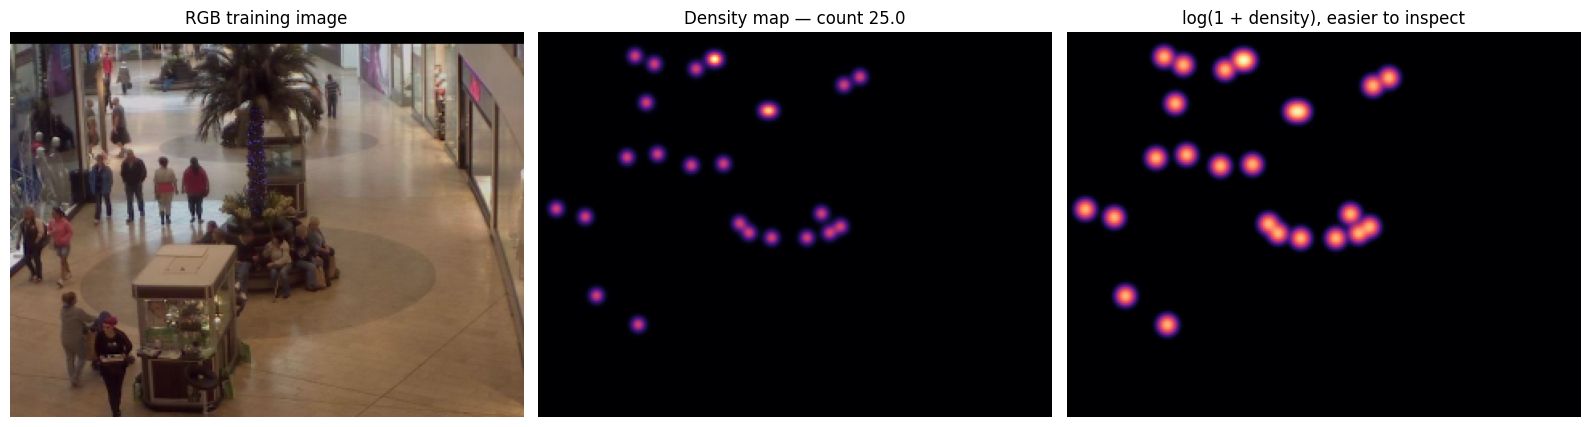

In [5]:
sample_image = batch_images[0]
sample_density = batch_maps[0, :, :, 0]
sample_count = sample_density.sum() / DENSITY_SCALE

figure, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(sample_image)
axes[0].set_title("RGB training image")
axes[0].axis("off")

axes[1].imshow(sample_density, cmap="magma")
axes[1].set_title(f"Density map — count {sample_count:.1f}")
axes[1].axis("off")

axes[2].imshow(np.log1p(sample_density), cmap="magma")
axes[2].set_title("log(1 + density), easier to inspect")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [6]:
def convolution_block(x, filters, name):
    x = tf.keras.layers.Conv2D(
        filters,
        kernel_size=3,
        padding="same",
        kernel_initializer="he_normal",
        name=f"{name}_conv1",
    )(x)
    x = tf.keras.layers.Activation(
        "relu",
        name=f"{name}_relu1",
    )(x)

    x = tf.keras.layers.Conv2D(
        filters,
        kernel_size=3,
        padding="same",
        kernel_initializer="he_normal",
        name=f"{name}_conv2",
    )(x)
    x = tf.keras.layers.Activation(
        "relu",
        name=f"{name}_relu2",
    )(x)

    return x


def build_density_unet():
    inputs = tf.keras.Input(
        shape=(INPUT_HEIGHT, INPUT_WIDTH, INPUT_CHANNELS),
        name="rgb_image",
    )

    # Encoder
    encoder_1 = convolution_block(
        inputs,
        16,
        "encoder1",
    )
    pooled_1 = tf.keras.layers.MaxPooling2D(
        pool_size=2,
        name="pool1",
    )(encoder_1)

    encoder_2 = convolution_block(
        pooled_1,
        32,
        "encoder2",
    )
    pooled_2 = tf.keras.layers.MaxPooling2D(
        pool_size=2,
        name="pool2",
    )(encoder_2)

    encoder_3 = convolution_block(
        pooled_2,
        64,
        "encoder3",
    )
    pooled_3 = tf.keras.layers.MaxPooling2D(
        pool_size=2,
        name="pool3",
    )(encoder_3)

    bottleneck = convolution_block(
        pooled_3,
        128,
        "bottleneck",
    )
    bottleneck = tf.keras.layers.SpatialDropout2D(
        0.15,
        name="bottleneck_dropout",
    )(bottleneck)

    # Decoder: bilinear resizing avoids checkerboard artifacts.
    decoder_3 = tf.keras.layers.UpSampling2D(
        size=2,
        interpolation="bilinear",
        name="upsample3",
    )(bottleneck)
    decoder_3 = tf.keras.layers.Conv2D(
        64,
        kernel_size=3,
        padding="same",
        activation="relu",
        name="decoder3_projection",
    )(decoder_3)
    decoder_3 = tf.keras.layers.Concatenate(
        name="skip3",
    )([decoder_3, encoder_3])
    decoder_3 = convolution_block(
        decoder_3,
        64,
        "decoder3",
    )

    decoder_2 = tf.keras.layers.UpSampling2D(
        size=2,
        interpolation="bilinear",
        name="upsample2",
    )(decoder_3)
    decoder_2 = tf.keras.layers.Conv2D(
        32,
        kernel_size=3,
        padding="same",
        activation="relu",
        name="decoder2_projection",
    )(decoder_2)
    decoder_2 = tf.keras.layers.Concatenate(
        name="skip2",
    )([decoder_2, encoder_2])
    decoder_2 = convolution_block(
        decoder_2,
        32,
        "decoder2",
    )

    decoder_1 = tf.keras.layers.UpSampling2D(
        size=2,
        interpolation="bilinear",
        name="upsample1",
    )(decoder_2)
    decoder_1 = tf.keras.layers.Conv2D(
        16,
        kernel_size=3,
        padding="same",
        activation="relu",
        name="decoder1_projection",
    )(decoder_1)
    decoder_1 = tf.keras.layers.Concatenate(
        name="skip1",
    )([decoder_1, encoder_1])
    decoder_1 = convolution_block(
        decoder_1,
        16,
        "decoder1",
    )

    density_output = tf.keras.layers.Conv2D(
        1,
        kernel_size=1,
        padding="same",
        activation="relu",
        name="density_map",
    )(decoder_1)

    return tf.keras.Model(
        inputs=inputs,
        outputs=density_output,
        name="mall_density_unet",
    )


@tf.keras.utils.register_keras_serializable(
    package="CrowdCounting"
)
def density_count_loss(y_true, y_pred):
    """
    Spatially weighted density regression plus an image-level count loss.

    The spatial weighting prevents the very large zero-background region from
    dominating learning. The count term encourages the map integral to match
    the number of people.
    """
    epsilon = tf.keras.backend.epsilon()

    sample_peak = tf.reduce_max(
        y_true,
        axis=(1, 2, 3),
        keepdims=True,
    )

    spatial_weight = (
        1.0
        + 5.0
        * y_true
        / (sample_peak + epsilon)
    )

    pixel_mse = tf.reduce_mean(
        spatial_weight
        * tf.square(y_pred - y_true)
    )

    true_count = (
        tf.reduce_sum(
            y_true,
            axis=(1, 2, 3),
        )
        / DENSITY_SCALE
    )

    predicted_count = (
        tf.reduce_sum(
            y_pred,
            axis=(1, 2, 3),
        )
        / DENSITY_SCALE
    )

    count_error = predicted_count - true_count
    absolute_error = tf.abs(count_error)

    # Huber count loss with delta=5.
    delta = 5.0
    count_huber = tf.where(
        absolute_error <= delta,
        0.5 * tf.square(count_error),
        delta * (absolute_error - 0.5 * delta),
    )

    return pixel_mse + 0.10 * tf.reduce_mean(count_huber)


@tf.keras.utils.register_keras_serializable(
    package="CrowdCounting"
)
def count_mae(y_true, y_pred):
    true_count = (
        tf.reduce_sum(
            y_true,
            axis=(1, 2, 3),
        )
        / DENSITY_SCALE
    )

    predicted_count = (
        tf.reduce_sum(
            y_pred,
            axis=(1, 2, 3),
        )
        / DENSITY_SCALE
    )

    return tf.reduce_mean(
        tf.abs(predicted_count - true_count)
    )


model = build_density_unet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=3e-4,
        clipnorm=1.0,
    ),
    loss=density_count_loss,
    metrics=[
        count_mae,
        tf.keras.metrics.MeanAbsoluteError(
            name="pixel_mae"
        ),
    ],
)

model.summary()

Model: "mall_density_unet"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 rgb_image (InputLayer)      [(None, 240, 320, 3)]        0         []                            
                                                                                                  
 encoder1_conv1 (Conv2D)     (None, 240, 320, 16)         448       ['rgb_image[0][0]']           
                                                                                                  
 encoder1_relu1 (Activation  (None, 240, 320, 16)         0         ['encoder1_conv1[0][0]']      
 )                                                                                                
                                                                                                  
 encoder1_conv2 (Conv2D)     (None, 240, 320, 16)         2320      ['encoder1_rel

In [7]:
from pathlib import Path
import os
import tensorflow as tf

OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save checkpoint weights rather than the entire model every epoch.
# This is safer when custom losses and metrics are being used.
BEST_WEIGHTS_PATH = (
    OUTPUT_DIR / "best_crowd_density_model.weights.h5"
)

TRAINING_LOG_PATH = (
    OUTPUT_DIR / "training_log.csv"
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(BEST_WEIGHTS_PATH),
        monitor="val_count_mae",
        mode="min",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_count_mae",
        mode="min",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1,
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_count_mae",
        mode="min",
        patience=12,
        restore_best_weights=True,
        verbose=1,
    ),

    tf.keras.callbacks.CSVLogger(
        filename=str(TRAINING_LOG_PATH),
        append=False,
    ),
]

history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=60,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/60


2026-08-01 16:42:28.859545: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmall_density_unet/bottleneck_dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


200/200 [==============================] - ETA: 0s - loss: 15.0468 - count_mae: 6.9677 - pixel_mae: 0.6852
Epoch 1: val_count_mae improved from inf to 4.39811, saving model to /kaggle/working/best_crowd_density_model.weights.h5
200/200 [==============================] - 53s 208ms/step - loss: 15.0468 - count_mae: 6.9677 - pixel_mae: 0.6852 - val_loss: 12.8432 - val_count_mae: 4.3981 - val_pixel_mae: 0.6939 - lr: 3.0000e-04
Epoch 2/60
200/200 [==============================] - ETA: 0s - loss: 11.7120 - count_mae: 8.1077 - pixel_mae: 0.5281
Epoch 2: val_count_mae improved from 4.39811 to 3.58741, saving model to /kaggle/working/best_crowd_density_model.weights.h5
200/200 [==============================] - 28s 140ms/step - loss: 11.7120 - count_mae: 8.1077 - pixel_mae: 0.5281 - val_loss: 8.9006 - val_count_mae: 3.5874 - val_pixel_mae: 0.4578 - lr: 3.0000e-04
Epoch 3/60
200/200 [==============================] - ETA: 0s - loss: 7.1949 - count_mae: 4.9361 - pixel_mae: 0.3715
Epoch 3: val_co

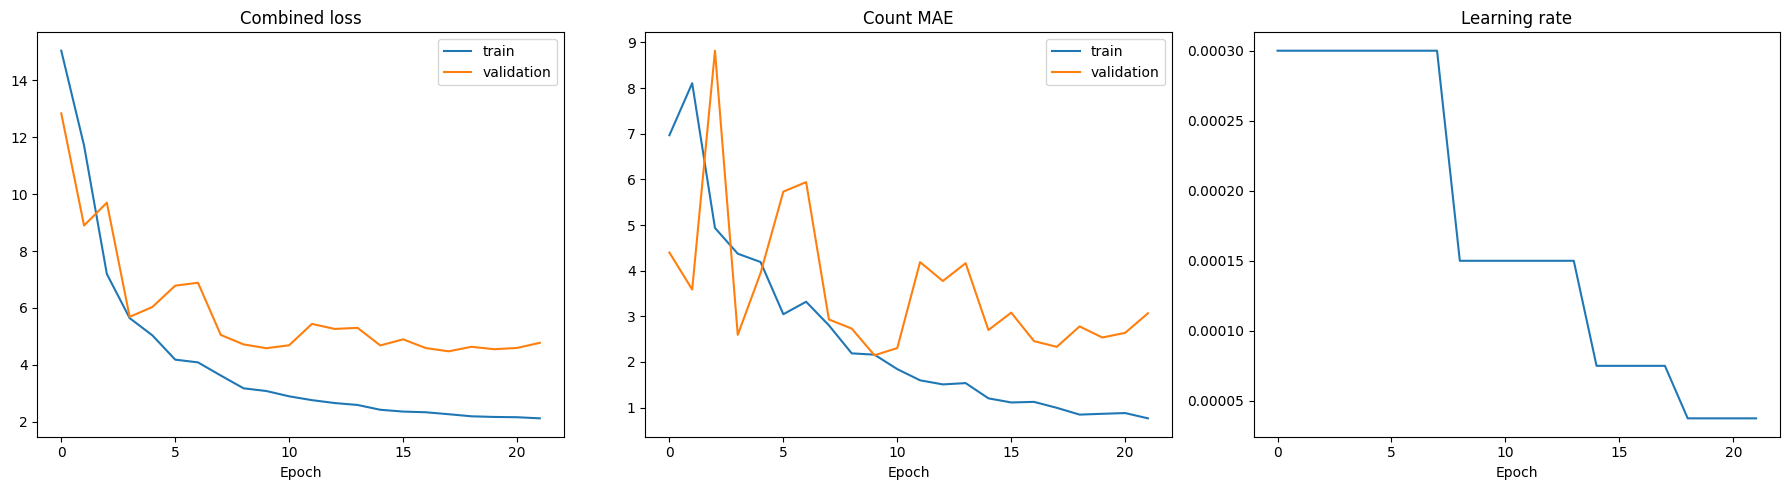

In [8]:
history_frame = pd.DataFrame(history.history)

figure, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_frame["loss"], label="train")
axes[0].plot(history_frame["val_loss"], label="validation")
axes[0].set_title("Combined loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_frame["count_mae"], label="train")
axes[1].plot(history_frame["val_count_mae"], label="validation")
axes[1].set_title("Count MAE")
axes[1].set_xlabel("Epoch")
axes[1].legend()

learning_rate_key = (
    "learning_rate"
    if "learning_rate" in history_frame.columns
    else "lr"
)

if learning_rate_key in history_frame.columns:
    axes[2].plot(history_frame[learning_rate_key])
    axes[2].set_title("Learning rate")
else:
    axes[2].text(
        0.5,
        0.5,
        "Learning-rate history was not recorded",
        ha="center",
        va="center",
    )
    axes[2].set_title("Learning rate")

axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.show()

Best checkpoint loaded: /kaggle/working/best_crowd_density_model.weights.h5
Validation MAE:       2.146
Validation RMSE:      2.721
Validation MSE:       7.404
Validation Pearson r: 0.891


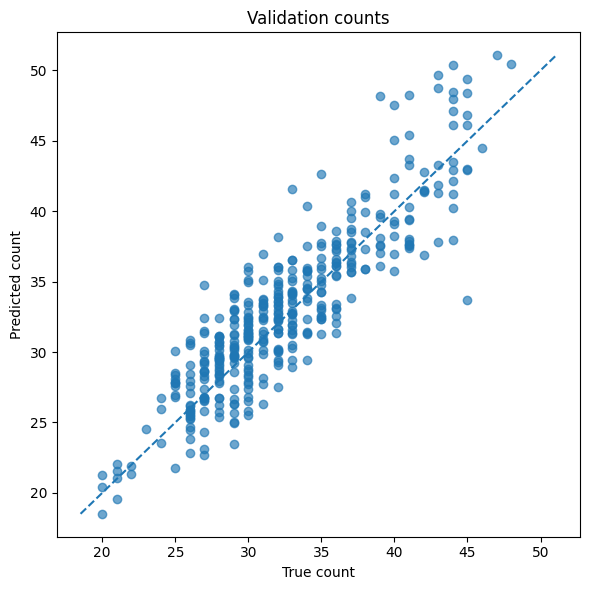

In [9]:
# Path created by the corrected training callback cell.
BEST_WEIGHTS_PATH = (
    Path("/kaggle/working")
    / "best_crowd_density_model.weights.h5"
)

if not BEST_WEIGHTS_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint not found: {BEST_WEIGHTS_PATH}"
    )

# Reuse the existing architecture and restore the best weights.
model.load_weights(
    str(BEST_WEIGHTS_PATH)
)

best_model = model

print("Best checkpoint loaded:", BEST_WEIGHTS_PATH)
true_counts = []
predicted_counts = []

for batch_index in range(len(valid_generator)):
    batch_images, batch_targets = valid_generator[batch_index]

    batch_predictions = best_model.predict(
        batch_images,
        verbose=0,
    )

    true_counts.extend(
        batch_targets.sum(axis=(1, 2, 3))
        / DENSITY_SCALE
    )

    predicted_counts.extend(
        batch_predictions.sum(axis=(1, 2, 3))
        / DENSITY_SCALE
    )

true_counts = np.asarray(true_counts)
predicted_counts = np.asarray(predicted_counts)

validation_mae = mean_absolute_error(
    true_counts,
    predicted_counts,
)

validation_rmse = mean_squared_error(
    true_counts,
    predicted_counts,
) ** 0.5

validation_mse = mean_squared_error(
    true_counts,
    predicted_counts,
)

if np.std(predicted_counts) > 0:
    validation_pearson, _ = stats.pearsonr(
        true_counts,
        predicted_counts,
    )
else:
    validation_pearson = np.nan

print(f"Validation MAE:       {validation_mae:.3f}")
print(f"Validation RMSE:      {validation_rmse:.3f}")
print(f"Validation MSE:       {validation_mse:.3f}")
print(f"Validation Pearson r: {validation_pearson:.3f}")

plt.figure(figsize=(6, 6))
plt.scatter(
    true_counts,
    predicted_counts,
    alpha=0.65,
)
limits = [
    min(true_counts.min(), predicted_counts.min()),
    max(true_counts.max(), predicted_counts.max()),
]
plt.plot(limits, limits, "--")
plt.xlabel("True count")
plt.ylabel("Predicted count")
plt.title("Validation counts")
plt.tight_layout()
plt.show()

True count:      30.00
Predicted count: 35.14


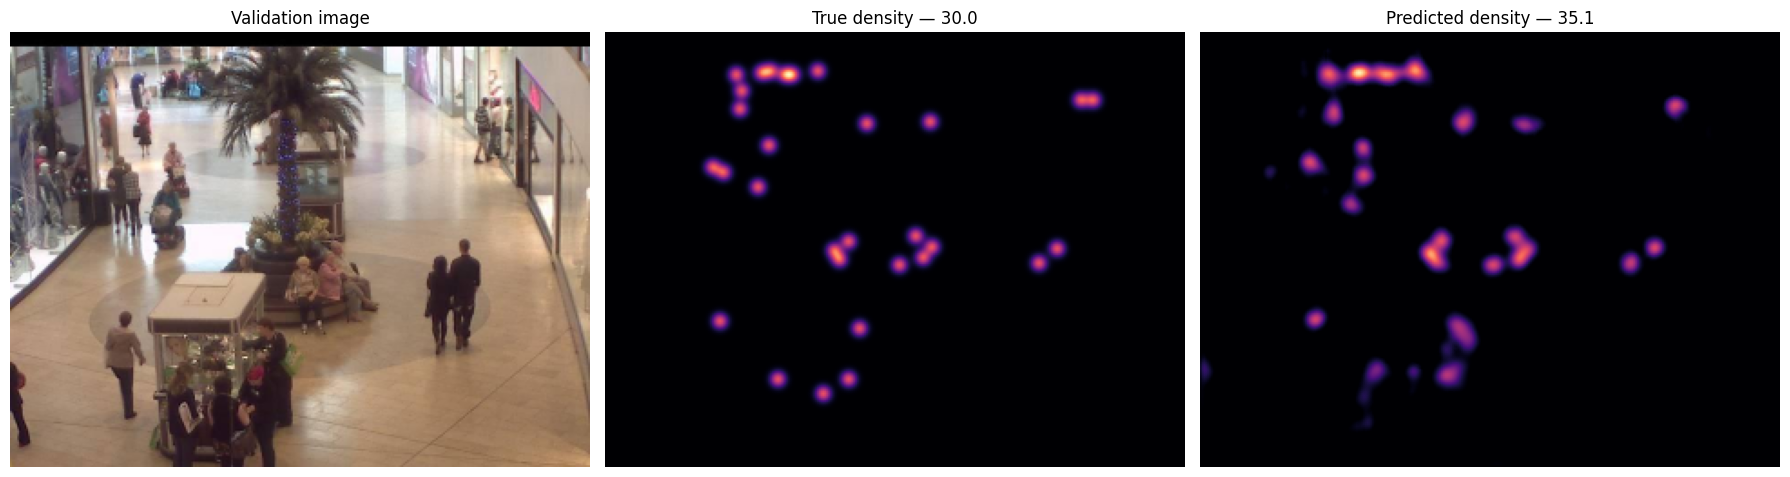

In [10]:
# Visual check on a validation frame, not a training frame.
validation_images, validation_targets = valid_generator[0]

sample_input = validation_images[0:1]
true_density = validation_targets[0, :, :, 0]

predicted_density = best_model.predict(
    sample_input,
    verbose=0,
)[0, :, :, 0]

true_count = true_density.sum() / DENSITY_SCALE
predicted_count = predicted_density.sum() / DENSITY_SCALE

print(f"True count:      {true_count:.2f}")
print(f"Predicted count: {predicted_count:.2f}")

shared_maximum = max(
    float(true_density.max()),
    float(predicted_density.max()),
)

figure, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(sample_input[0])
axes[0].set_title("Validation image")
axes[0].axis("off")

axes[1].imshow(
    true_density,
    cmap="magma",
    vmin=0,
    vmax=shared_maximum,
)
axes[1].set_title(f"True density — {true_count:.1f}")
axes[1].axis("off")

axes[2].imshow(
    predicted_density,
    cmap="magma",
    vmin=0,
    vmax=shared_maximum,
)
axes[2].set_title(
    f"Predicted density — {predicted_count:.1f}"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [11]:
# Export a clean inference model plus a weight-only fallback.
FINAL_MODEL_PATH = OUTPUT_DIR / "crowd_counting_unet.keras"
WEIGHTS_PATH = OUTPUT_DIR / "crowd_counting_unet.weights.h5"
METADATA_PATH = OUTPUT_DIR / "model_metadata.json"

# The checkpoint was created with the same tf.keras stack and explicit Input.
best_model.save(FINAL_MODEL_PATH)
best_model.save_weights(WEIGHTS_PATH)

metadata = {
    "model_name": best_model.name,
    "tensorflow_version": tf.__version__,
    "input_height": INPUT_HEIGHT,
    "input_width": INPUT_WIDTH,
    "input_channels": INPUT_CHANNELS,
    "input_color_order": "RGB",
    "normalization": "float32 pixels divided by 255.0",
    "density_scale": DENSITY_SCALE,
    "count_formula": "sum(predicted_density_map) / density_scale",
    "validation_mae": float(validation_mae),
    "validation_rmse": float(validation_rmse),
    "validation_mse": float(validation_mse),
    "validation_pearson_r": (
        None
        if np.isnan(validation_pearson)
        else float(validation_pearson)
    ),
    "training_split": "first 80% train, last 20% validation",
    "training_dataset": "Mall fixed-camera dataset",
}

METADATA_PATH.write_text(
    json.dumps(metadata, indent=2)
)

# Reload verification.
reloaded_model = tf.keras.models.load_model(
    FINAL_MODEL_PATH,
    compile=False,
)

verification_output = reloaded_model.predict(
    sample_input,
    verbose=0,
)

maximum_difference = float(
    np.max(
        np.abs(
            verification_output
            - best_model.predict(sample_input, verbose=0)
        )
    )
)

print("Saved:", FINAL_MODEL_PATH)
print("Saved:", WEIGHTS_PATH)
print("Saved:", METADATA_PATH)
print(
    "Reload prediction maximum difference:",
    maximum_difference,
)

assert maximum_difference < 1e-5

Saved: /kaggle/working/crowd_counting_unet.keras
Saved: /kaggle/working/crowd_counting_unet.weights.h5
Saved: /kaggle/working/model_metadata.json
Reload prediction maximum difference: 0.0
